In this task, we are using the Mall Customers dataset which contains basic information about customers such as age, gender, income, and spending score. The goal is to understand customer behavior and group similar customers together.

#1. Import Libraries

In [3]:
# basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machnie learning libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

##Uploading Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


#2. Loading Dataset

In [5]:
# loading dataset
df = pd.read_csv("Mall_Customers.csv")

# showing  first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#3.Initial Data Inspection
First, we explore the dataset to understand its structure, check for dataset shape and general information

In [21]:
# Check dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# checking info
df.info()



Number of rows: 200
Number of columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
 5   Cluster                 200 non-null    int32  
 6   Cluster Label           200 non-null    object 
 7   PCA1                    200 non-null    float64
 8   PCA2                    200 non-null    float64
dtypes: float64(2), int32(1), int64(4), object(2)
memory usage: 13.4+ KB


In [26]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2
count,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02
mean,100.500000,38.850000,60.560000,50.200000,1.400000,1.065814e-16,3.552714e-17
std,57.879185,13.969007,26.264721,25.823522,1.449311,1.007461e+00,9.975332e-01
min,1.000000,18.000000,15.000000,1.000000,0.000000,-2.417385e+00,-2.461307e+00
25%,50.750000,28.750000,41.500000,34.750000,0.000000,-4.323694e-01,-4.499386e-01
50%,100.500000,36.000000,61.500000,50.000000,1.000000,-1.251055e-01,-1.185058e-01
75%,150.250000,49.000000,78.000000,73.000000,3.000000,3.607120e-01,3.008815e-01
max,200.000000,70.000000,137.000000,99.000000,4.000000,2.963498e+00,2.947027e+00


# 4. Data Preprocessing

Before applying clustering, the dataset is cleaned and prepared to ensure that the features used for customer segmentation are suitable for K-Means clustering.

The preprocessing steps include:

- Checking for missing values
- Checking for duplicate records
- Identifying and managing irrelevant columns
- Checking data types
- Selecting relevant customer features
- Scaling numerical features
- Evaluating whether categorical variables are required for clustering

### Data Types

The data types of all variables are checked to determine whether any conversion or encoding is required before clustering.

In [18]:
# Check data types
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64
Cluster,int32
Cluster Label,object
PCA1,float64
PCA2,float64


### Missing Value Handling

Missing values were checked for all columns. The dataset does not contain missing values, so no imputation or row removal was required.

In [19]:
# checking for missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Cluster,0
Cluster Label,0
PCA1,0
PCA2,0


### Duplicate Records

Duplicate records were checked to ensure that the same customer record was not unintentionally included more than once.

In [20]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

### Managing Irrelevant Features

`CustomerID` is an identifier assigned to each customer and does not represent customer behavior or characteristics. Therefore, it is excluded from the clustering features.

The remaining customer attributes are considered for segmentation based on their relevance to customer characteristics and spending behavior.

### Categorical Variable Consideration

`Gender` is a categorical variable. It is retained in the dataset for exploratory analysis and later interpretation of customer segments.

For K-Means clustering, the numerical customer characteristics are used because the clustering process is based on distances between feature values. Therefore, Gender is not included in the initial clustering feature set.

### Selected Features

The selected features represent three important customer characteristics:

- **Age** – demographic characteristic
- **Annual Income** – economic characteristic
- **Spending Score** – customer spending behavior

These variables provide meaningful information for identifying groups of customers with similar characteristics.

In [22]:
# Select relevant numerical features for clustering
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [23]:
# Summary statistics of selected clustering features
X.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


# 5. EDA(Exploratory Data Analysis)



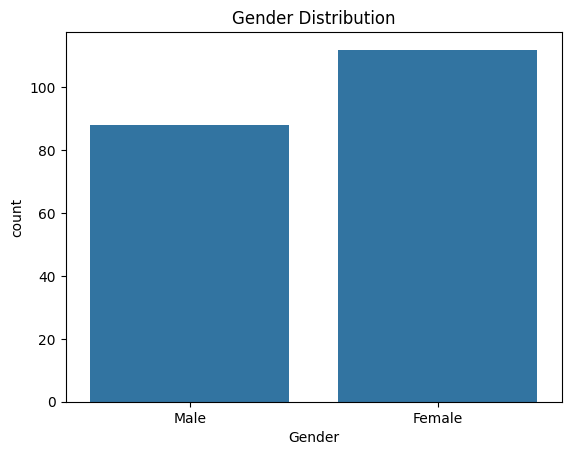

In [7]:
# gender distribution
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

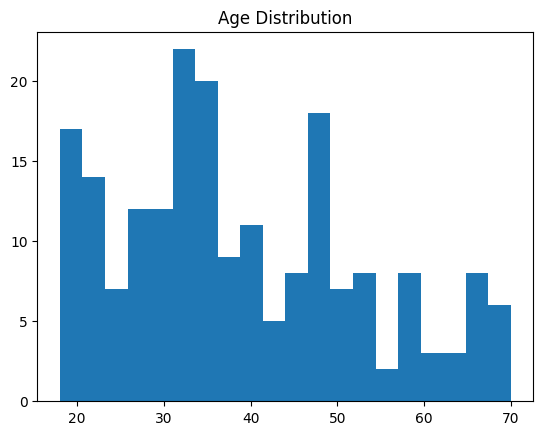

In [8]:
# age distribution
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

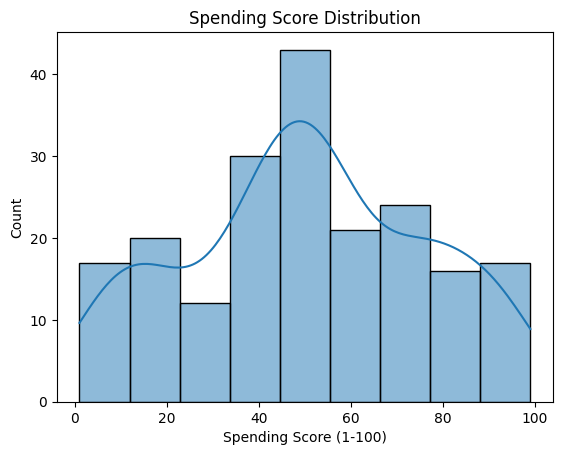

In [9]:
# spending score distribution
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

#5. Feature Scaling

K-Means clustering is distance-based, so features with larger numerical ranges can have a greater influence on the clustering process.

To ensure that all selected features contribute fairly, StandardScaler is used to standardize the numerical variables.

After scaling, the features have approximately:

- Mean = 0
- Standard deviation = 1

This produces a comparable scale for Age, Annual Income, and Spending Score before applying K-Means clustering.

In [24]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [25]:
# Verify the scaled features
X_scaled_df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-1.021405e-16,-2.131628e-16,-1.465494e-16
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.496335e+00,-1.738999e+00,-1.910021e+00
25%,-7.248436e-01,-7.275093e-01,-5.997931e-01
50%,-2.045351e-01,3.587926e-02,-7.764312e-03
75%,7.284319e-01,6.656748e-01,8.851316e-01
max,2.235532e+00,2.917671e+00,1.894492e+00


#7. Determine Optimal Number of Clusters

### Elbow Method

The Elbow Method is used to identify a suitable number of clusters for K-Means clustering. It calculates the Within-Cluster Sum of Squares (WCSS) for different values of K. The point where the decrease in WCSS begins to slow down indicates a possible optimal number of clusters.

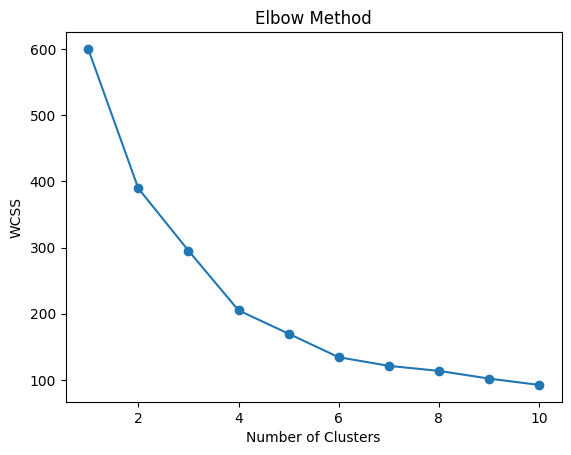

In [27]:

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Silhouette Score

The Silhouette Score is used to further evaluate the quality of clustering for different numbers of clusters. It measures how similar each customer is to its assigned cluster compared with other clusters.

A higher Silhouette Score indicates better-defined and more separated clusters.

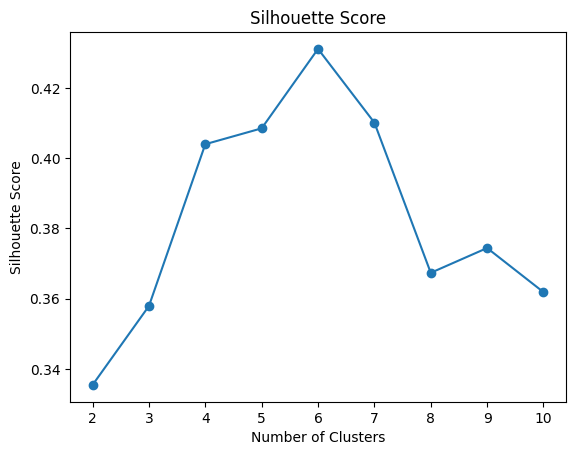

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

#8. K-Means Clustering

### Selecting the Optimal Number of Clusters

The Elbow Method suggests that the improvement in WCSS begins to slow down around 4–5 clusters. However, the Silhouette Score reaches its highest value at 6 clusters, indicating better-defined and more separated customer groups.

Based on the combined results of the Elbow Method and Silhouette Score, 6 clusters are selected for the final K-Means model.

In [29]:
# Final K-Means model with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster Label,PCA1,PCA2
0,1,Male,19,15,39,2,Careful Spenders,-1.537109,-0.922207
1,2,Male,21,15,81,2,Medium Spender,-0.384168,-2.075149
2,3,Female,20,16,6,5,Careful Spenders,-2.416002,0.010665
3,4,Female,23,16,77,2,Medium Spender,-0.466982,-1.938355
4,5,Female,31,17,40,5,Careful Spenders,-1.455678,-0.895678


### Cluster-wise Analysis

After applying K-Means with 6 clusters, the average age, annual income, and spending score of each cluster are analyzed.

This helps us understand the characteristics of each customer segment and assign meaningful names based on their demographic and spending behavior.

In [30]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.33,54.27,49.07
1,32.69,86.54,82.13
2,25.56,26.48,76.24
3,26.12,59.42,44.45
4,44.00,90.13,17.93
5,45.52,26.29,19.38


Labeling of Clusters

In [31]:
df['Cluster Label'] = df['Cluster'].map({
    0: "Older Medium-Income Moderate Spenders",
    1: "Young High-Income High Spenders",
    2: "Young Low-Income High Spenders",
    3: "Young Medium-Income Moderate Spenders",
    4: "Older High-Income Low Spenders",
    5: "Older Low-Income Low Spenders"
})

df[['Cluster', 'Cluster Label']].head()

,Cluster,Cluster Label
0,2,Young Low-Income High Spenders
1,2,Young Low-Income High Spenders
2,5,Older Low-Income Low Spenders
3,2,Young Low-Income High Spenders
4,5,Older Low-Income Low Spenders


#9. Cluster Visualization

The customer segments are visualized using Annual Income and Spending Score, which are two key variables for understanding customer purchasing behavior.

Different colors represent the six K-Means clusters. The visualization helps identify customers with similar income and spending patterns and provides a clear view of the separation between customer segments.

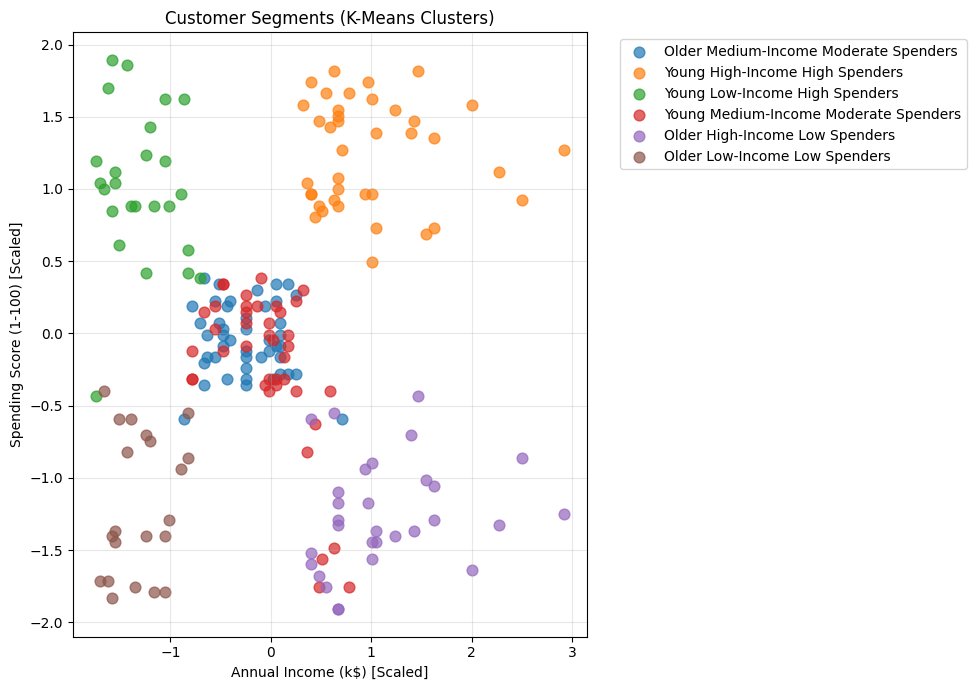

In [32]:
# Visualizing the 6 Customer Clusters

plt.figure(figsize=(10, 7))

# Plot each cluster
for cluster in sorted(df['Cluster'].unique()):
    plt.scatter(
        X_scaled[df['Cluster'] == cluster, 1],   # Annual Income
        X_scaled[df['Cluster'] == cluster, 2],   # Spending Score
        label=df.loc[df['Cluster'] == cluster, 'Cluster Label'].iloc[0],
        alpha=0.7,
        s=60
    )

plt.title("Customer Segments (K-Means Clusters)")
plt.xlabel("Annual Income (k$) [Scaled]")
plt.ylabel("Spending Score (1-100) [Scaled]")

plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### Correlation Analysis

A correlation heatmap is used to examine the relationships between the numerical customer features. It helps identify whether Age, Annual Income, and Spending Score have strong or weak linear relationships with each other.

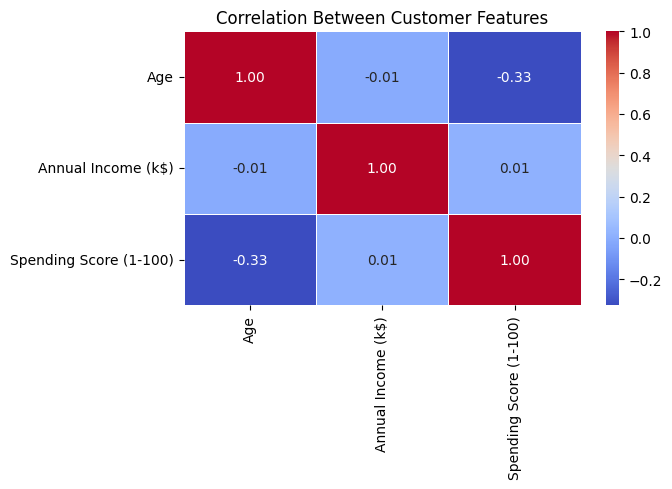

In [33]:
# Correlation Heatmap

plt.figure(figsize=(7, 5))

correlation_matrix = df[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Customer Features")
plt.tight_layout()
plt.show()

### PCA-Based Cluster Visualization

Principal Component Analysis (PCA) is used to reduce the three-dimensional feature space to two dimensions for visualization.

The K-Means clustering is performed using the original scaled features. PCA is only used to create a 2D representation of the customer segments, making it easier to observe the separation between the six clusters.

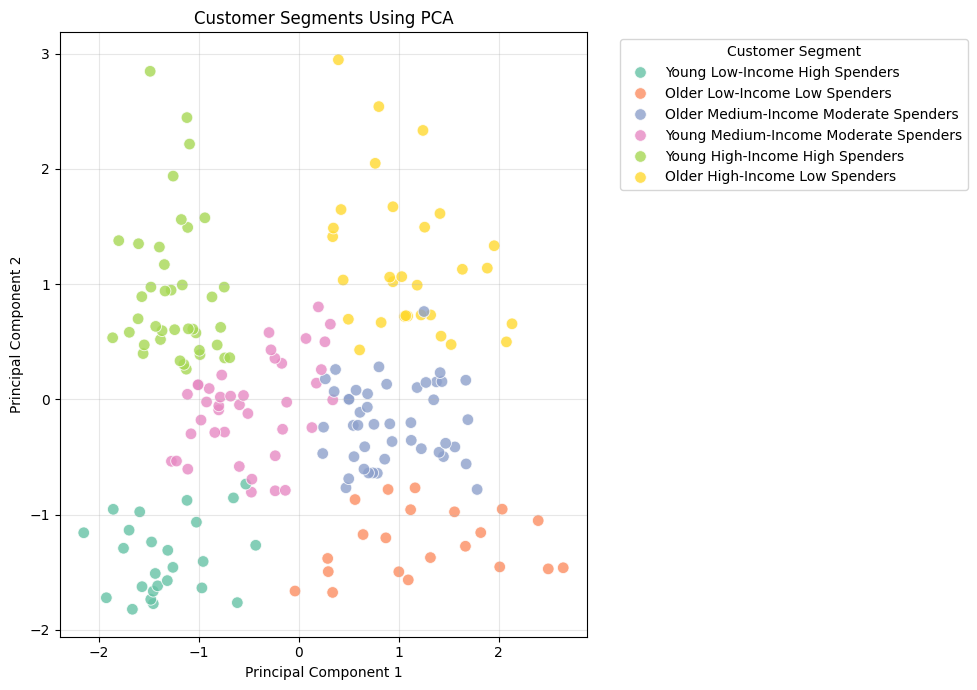

In [34]:
# PCA for 2D Cluster Visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster Label',
    palette='Set2',
    s=70,
    alpha=0.8
)

plt.title("Customer Segments Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scatter Plot

A scatter plot is used to visualize the relationship between **Annual Income** and **Spending Score** for individual customers. Each point represents one customer, while different colors represent the six customer segments identified by K-Means clustering.

This visualization helps identify differences in customers' income and spending behavior and shows how the customer segments are distributed across these two important variables.

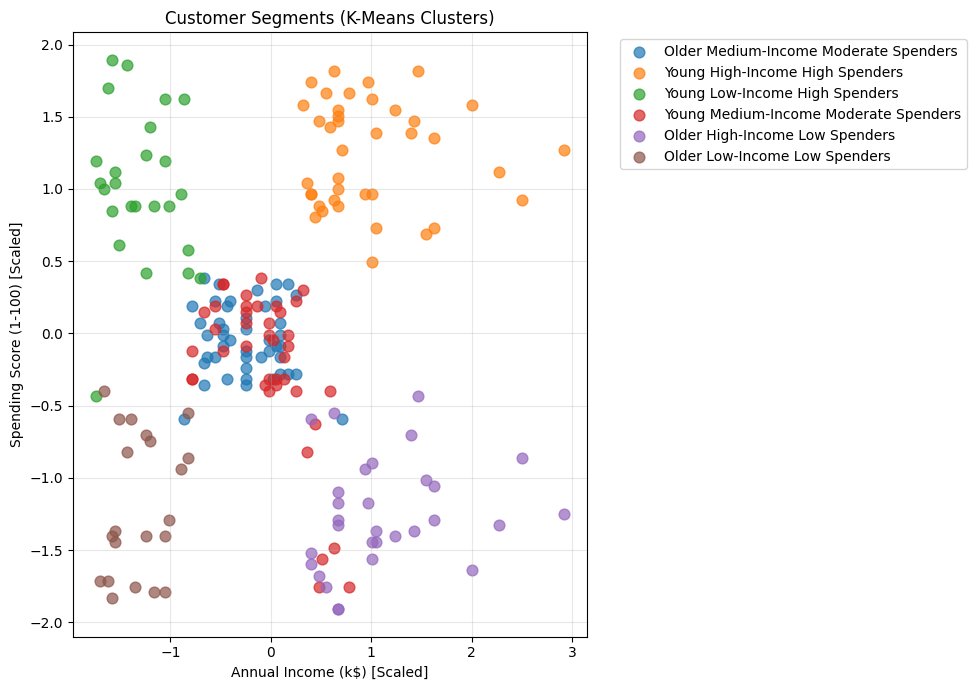

In [37]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df['Cluster'].unique()):
    plt.scatter(
        X_scaled[df['Cluster'] == cluster, 1],
        X_scaled[df['Cluster'] == cluster, 2],
        label=df.loc[df['Cluster'] == cluster, 'Cluster Label'].iloc[0],
        alpha=0.7,
        s=60
    )

plt.title("Customer Segments (K-Means Clusters)")
plt.xlabel("Annual Income (k$) [Scaled]")
plt.ylabel("Spending Score (1-100) [Scaled]")

plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

#10. Segment Interpretation

Based on the cluster-wise averages, the six customer segments can be summarized as follows:

- **Older High-Income Low Spenders:** Older customers with high income but low spending.
- **Older Low-Income Low Spenders:** Older customers with low income and low spending.
- **Older Medium-Income Moderate Spenders:** Older customers with moderate income and moderate spending.
- **Young High-Income High Spenders:** Younger customers with high income and high spending.
- **Young Low-Income High Spenders:** Younger customers with low income but high spending.
- **Young Medium-Income Moderate Spenders:** Younger customers with moderate income and moderate spending.

These segments show distinct differences in age, income, and spending behavior, making them useful for targeted customer strategies.

In [36]:
#  Segment Interpretation

cluster_summary = df.groupby('Cluster Label').agg(
    Customer_Count=('Cluster', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending_Score=('Spending Score (1-100)', 'mean')
).round(2)

# Calculate percentage of customers in each segment
cluster_summary['Percentage'] = (
    cluster_summary['Customer_Count'] / len(df) * 100
).round(2)

cluster_summary

,Customer_Count,Average_Age,Average_Income,Average_Spending_Score,Percentage
Cluster Label,,,,,
Older High-Income Low Spenders,30,44.00,90.13,17.93,15.0
Older Low-Income Low Spenders,21,45.52,26.29,19.38,10.5
Older Medium-Income Moderate Spenders,45,56.33,54.27,49.07,22.5
Young High-Income High Spenders,39,32.69,86.54,82.13,19.5
Young Low-Income High Spenders,25,25.56,26.48,76.24,12.5
Young Medium-Income Moderate Spenders,40,26.12,59.42,44.45,20.0


#11. Business Insights & Recommendations

The identified segments can support targeted marketing and customer engagement strategies:

- **High-Income High Spenders:** Premium products and loyalty programs.
- **Low-Income High Spenders:** Discounts and affordable offers.
- **Moderate Spenders:** Personalized recommendations and promotions.
- **High-Income Low Spenders:** Targeted engagement and incentives.
- **Low-Income Low Spenders:** Value-based and budget-friendly offers.
- **Moderate-Income Customers:** Retention campaigns and personalized offers.

Overall, customer segmentation can help businesses target customers according to their spending behavior and demographic characteristics.

#12.Conclusion
- K-Means clustering divided customers into six distinct segments based on age, income, and spending behavior.
- The segments show clear differences between high, moderate, and low spending patterns.
- These groups can help businesses understand customer behavior and develop targeted marketing and engagement strategies.
- Overall, customer segmentation provides useful insights for personalized offers, customer retention, and better marketing decisions.